# Día 3 · Cuaderno 9 — Manipulación y visualización de datos

**Programar para enseñar — Python e IA generativa para Humanidades Digitales**
Formación docente para EH1023 · Pontificia Universidad Javeriana, Facultad de Ingeniería

*(Segundo bloque del Día 3 — 2 horas)*

---

Esta mañana aprendiste a leer archivos línea por línea. Eso funciona, pero para **tablas de datos** hay
una herramienta mucho más potente: **pandas**. Y para convertir esos datos en **gráficos**, usaremos
**matplotlib**. Al terminar podrás:

- Cargar una tabla (CSV) en un **DataFrame** y explorarla.
- **Filtrar**, **contar** y **agrupar** datos.
- Crear **gráficos** de barras y un histograma.
- Leer un gráfico con mirada crítica.

> 💡 En **Colab** `pandas` y `matplotlib` ya están instalados. Si trabajas **local**, los instalaste
> con el monitor (Cuaderno 8). Trabajaremos con una tabla de **obras literarias** del repositorio.


## 1. Cargar la tabla con pandas

`pandas` puede leer un CSV **directamente desde una URL**. Lo guardamos en una variable llamada `df`
(de *DataFrame*, el nombre que pandas da a una tabla).


In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/calderonf/curso-python-humanidades-digitales/main/datos/obras_literarias.csv"
df = pd.read_csv(url)

df.head()   # muestra las primeras filas

,titulo,autor,anio,genero,paginas
0,Don Quijote de la Mancha,Miguel de Cervantes,1605,Novela,863
1,La vida es sueno,Pedro Calderon de la Barca,1635,Teatro,120
2,Cien anios de soledad,Gabriel Garcia Marquez,1967,Novela,471
3,Pedro Paramo,Juan Rulfo,1955,Novela,124
4,Rayuela,Julio Cortazar,1963,Novela,736


## 2. Explorar la tabla

Antes de analizar, conviene mirar el tamaño y las columnas.


In [2]:
print("Filas y columnas:", df.shape)
print("Columnas:", list(df.columns))
print("\nTipos de dato por columna:")
print(df.dtypes)

Filas y columnas: (30, 5)
Columnas: ['titulo', 'autor', 'anio', 'genero', 'paginas']

Tipos de dato por columna:
titulo       str
autor        str
anio       int64
genero       str
paginas    int64
dtype: object


Para ver una sola columna, se usa `df["nombre_columna"]`:


In [3]:
print(df["genero"])

0     Novela
1     Teatro
2     Novela
3     Novela
4     Novela
5     Cuento
6     Cuento
7     Novela
8     Poesia
9     Poesia
10    Poesia
11    Novela
12    Teatro
13    Poesia
14    Ensayo
15    Novela
16    Novela
17    Cuento
18    Novela
19    Novela
20    Cuento
21    Novela
22    Novela
23    Novela
24    Novela
25    Teatro
26    Poesia
27    Cuento
28    Ensayo
29     Comic
Name: genero, dtype: str


Y para un resumen numérico rápido de la columna de años o páginas:


In [4]:
print(df["anio"].describe())
print("\nAnio mas antiguo:", df["anio"].min())
print("Anio mas reciente:", df["anio"].max())

count      30.00000
mean     1932.30000
std        87.34993
min      1605.00000
25%      1935.50000
50%      1950.50000
75%      1963.75000
max      1998.00000
Name: anio, dtype: float64

Anio mas antiguo: 1605
Anio mas reciente: 1998


## 3. Filtrar filas

Podemos quedarnos solo con las filas que cumplen una condición. Por ejemplo, las obras **posteriores a 1950**:


In [5]:
obras_recientes = df[df["anio"] > 1950]
print("Obras posteriores a 1950:", len(obras_recientes))
obras_recientes[["titulo", "autor", "anio"]].head(10)

Obras posteriores a 1950: 15


,titulo,autor,anio
2,Cien anios de soledad,Gabriel Garcia Marquez,1967
3,Pedro Paramo,Juan Rulfo,1955
4,Rayuela,Julio Cortazar,1963
6,El llano en llamas,Juan Rulfo,1953
7,La casa de los espiritus,Isabel Allende,1982
11,La colmena,Camilo Jose Cela,1951
15,Los detectives salvajes,Roberto Bolano,1998
16,La region mas transparente,Carlos Fuentes,1958
17,Aura,Carlos Fuentes,1962
19,Sobre heroes y tumbas,Ernesto Sabato,1961


## 4. Contar por categoría con `value_counts()`

¿Cuántas obras hay de cada género? Una sola línea lo resuelve:


In [6]:
conteo_generos = df["genero"].value_counts()
print(conteo_generos)

genero
Novela    14
Cuento     5
Poesia     5
Teatro     3
Ensayo     2
Comic      1
Name: count, dtype: int64


## 5. Agrupar con `groupby()`

`groupby` permite calcular algo **por grupo**. Por ejemplo, el promedio de páginas por género:


In [39]:
paginas_por_genero = df.groupby("genero")["paginas"].mean()
print(paginas_por_genero.round(1))

genero
Comic     512.0
Cuento    186.6
Ensayo    350.5
Novela    411.4
Poesia    154.0
Teatro    108.7
Name: paginas, dtype: float64


## 6. Primer gráfico: barras por género

Ahora visualizamos. Importamos `matplotlib` y dibujamos cuántas obras hay por género.


Matplotlib is building the font cache; this may take a moment.


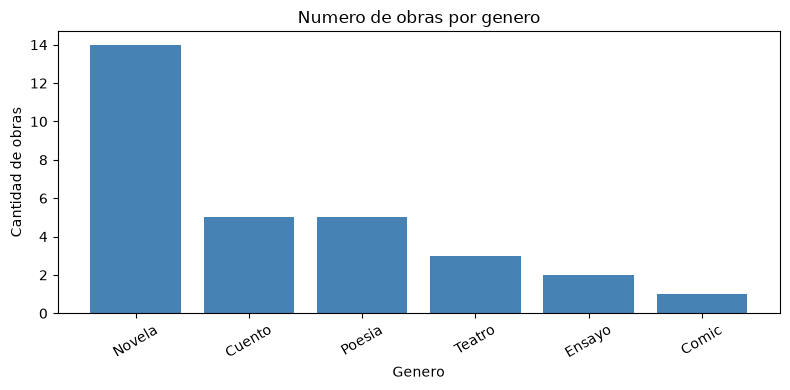

In [8]:
import matplotlib.pyplot as plt

conteo_generos = df["genero"].value_counts()

plt.figure(figsize=(8, 4))
plt.bar(conteo_generos.index, conteo_generos.values, color="steelblue")
plt.title("Numero de obras por genero")
plt.xlabel("Genero")
plt.ylabel("Cantidad de obras")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 7. Segundo gráfico: histograma de años

Un **histograma** muestra cómo se reparten los años de publicación: ¿se concentran en alguna época?


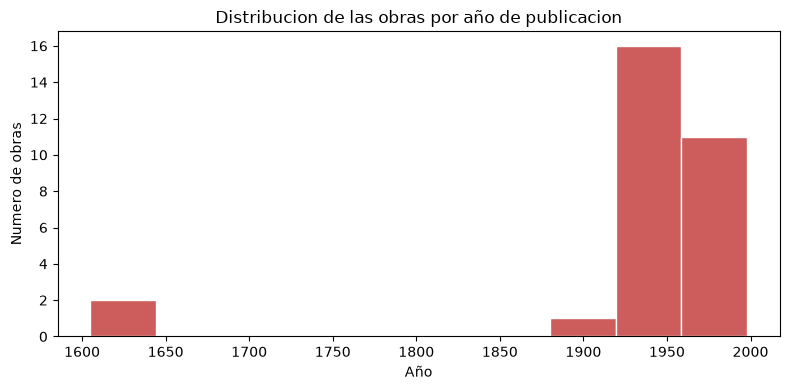

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(df["anio"], bins=10, color="indianred", edgecolor="white")
plt.title("Distribucion de las obras por año de publicacion")
plt.xlabel("Año")
plt.ylabel("Numero de obras")
plt.tight_layout()
plt.show()

> 🧭 **Nota para docentes — leer un gráfico con sentido crítico.** Un gráfico **no es neutral**:
> el número de barras del histograma (`bins`), la escala o los colores cambian la historia que cuenta.
> Una gran actividad para humanidades es pedir a los estudiantes que **interpreten** lo que ven
> ("¿por qué se concentran las obras en el siglo XX?") y que cuestionen las decisiones de diseño,
> en vez de tomar el gráfico como una verdad cerrada.


## 8. Ejercicios graduados

Avanza a tu ritmo. **No es obligatorio llegar al reto.** (Usan el `df` ya cargado.)

**Nivel 1 (base).** Muestra solo las filas cuyo `genero` sea `"Novela"`
(pista: `df[df["genero"] == "Novela"]`).

**Nivel 2.** Calcula el número de obras por **autor** con `value_counts()` y muéstralo.

**Reto (opcional).** Haz un gráfico de barras del **promedio de páginas por género**
(pista: ya lo calculaste en la sección 5; puedes dibujarlo con `.plot(kind="bar")`).


In [10]:
# Tu solucion del Nivel 1:
df[df['genero'] == 'Novela']


,titulo,autor,anio,genero,paginas
0,Don Quijote de la Mancha,Miguel de Cervantes,1605,Novela,863
2,Cien anios de soledad,Gabriel Garcia Marquez,1967,Novela,471
3,Pedro Paramo,Juan Rulfo,1955,Novela,124
4,Rayuela,Julio Cortazar,1963,Novela,736
7,La casa de los espiritus,Isabel Allende,1982,Novela,433
11,La colmena,Camilo Jose Cela,1951,Novela,384
15,Los detectives salvajes,Roberto Bolano,1998,Novela,609
16,La region mas transparente,Carlos Fuentes,1958,Novela,460
18,El tunel,Ernesto Sabato,1948,Novela,158
19,Sobre heroes y tumbas,Ernesto Sabato,1961,Novela,486


<details>
<summary>👀 Solución posible del Nivel 1</summary>

```python
novelas = df[df["genero"] == "Novela"]
novelas[["titulo", "autor", "anio"]]
```
</details>


In [16]:
# Tu solucion del Nivel 2:
df['autor'].value_counts()

autor
Gabriel Garcia Marquez        4
Federico Garcia Lorca         4
Pablo Neruda                  3
Juan Rulfo                    2
Jorge Luis Borges             2
Carlos Fuentes                2
Ernesto Sabato                2
Miguel de Cervantes           1
Pedro Calderon de la Barca    1
Julio Cortazar                1
Isabel Allende                1
Juan Ramon Jimenez            1
Camilo Jose Cela              1
Octavio Paz                   1
Roberto Bolano                1
Adolfo Bioy Casares           1
Miguel Angel Asturias         1
Quino                         1
Name: count, dtype: int64

<details>
<summary>👀 Solución posible del Nivel 2</summary>

```python
print(df["autor"].value_counts())
```
</details>


In [38]:
paginas_por_genero = df.paginas_por_genero

AttributeError: 'DataFrame' object has no attribute 'paginas_por_genero'

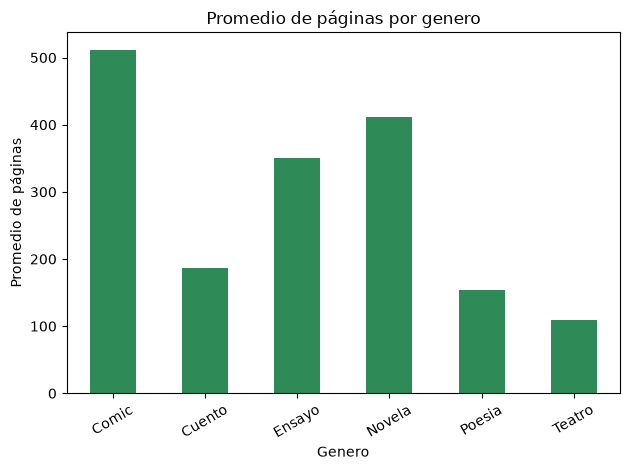

In [40]:
# Tu solucion del Reto (opcional):


paginas_por_genero.plot(kind= 'bar', color = 'seagreen')
plt.title("Promedio de páginas por genero")
plt.xlabel("Genero")
plt.ylabel("Promedio de páginas")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

<details>
<summary>👀 Solución posible del Reto</summary>

```python
import matplotlib.pyplot as plt
paginas_por_genero = df.groupby("genero")["paginas"].mean()
paginas_por_genero.plot(kind="bar", color="seagreen")
plt.title("Promedio de paginas por genero")
plt.ylabel("Paginas (promedio)")
plt.tight_layout()
plt.show()
```
</details>


> 🧭 **Nota para docentes — graduar el reto.** El Nivel 1 es un filtro (idea ya vista), el Nivel 2
> reusa `value_counts()` sobre otra columna, y el reto combina `groupby` + gráfico. Como siempre:
> **ustedes delimitan el taller**. Con pandas es fácil pedir demasiado de golpe; conviene avanzar de
> a una idea por vez para que la "primera victoria" llegue pronto.


---

## Cierre del Día 3

Hoy tu programa aprendió a **leer y escribir archivos**, a **sobrevivir a los errores**, y a
**manipular y visualizar datos** con pandas y matplotlib. Con esto ya puedes tomar una tabla
humanística y hacerla **hablar** con un gráfico.

### Mañana (Día 4)

Daremos el salto a la **inteligencia artificial generativa para la docencia**: cómo usar
**TecGPT, Gemini y Copilot** para producir, explicar y corregir código de forma **crítica**, y cómo
diseñar actividades y criterios de evaluación para el aula. Justo el tema que más inquietud despertó
en la encuesta inicial: cómo aprovechar la IA sin que los estudiantes dependan ciegamente de ella.

> Guarda tu trabajo con **Archivo → Guardar una copia en Drive**. ¡Excelente jornada!
